# Evaluate Personality Parametrizations

Compare 7 personas (1 default + 6 single-trait variants) across both simulator families — `PatientsWithPersonality` and `PatientSimPatient` — along three axes:

1. **HEXACO reconstruction deviation** per persona, side-by-side per simulator.
2. **Conversational diversity** via 2-PC projection of sentence embeddings.
3. **Information preservation** under persona change (profile fidelity).

A single persona color palette is used throughout.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import logging

os.chdir("..")
logging.getLogger().setLevel(logging.WARNING)

In [2]:
import pandas as pd

from patient_simulator.misc.plotting import (
    plot_hexaco_deviation_grid,
    plot_personality_extreme_difference,
)
from patient_simulator.misc.diversity import (
    embed_conversations,
    pca_nd,
    plot_diversity_overview,
    compute_diversity_stats,
)

In [3]:
MODEL_NAME = "gemini-3.1-flash-lite-preview"
ROOT = "results/patient_comparison_default"

PERSONA_MAP = {
    "PatientsWithPersonality_H2_E1_X1_A2_C2_O1_LB": "Default",
    "PatientSimPatient_persplain_cefrB_dazednormal_recallhigh": "Default",
    "PatientsWithPersonality_H3_E1_X1_A1_C1_O1_LB": "Dishonest",
    "PatientSimPatient_persdistrust_cefrB_dazednormal_recalllow": "Dishonest",
    "PatientsWithPersonality_H1_E3_X1_A1_C1_O1_LB": "Emotional",
    "PatientSimPatient_persoveranxious_cefrB_dazednormal_recallhigh": "Emotional",
    "PatientsWithPersonality_H1_E1_X3_A1_C1_O1_LB": "Extraverted",
    "PatientSimPatient_persverbose_cefrB_dazednormal_recallhigh": "Extraverted",
    "PatientsWithPersonality_H1_E1_X1_A3_C1_O1_LB": "Frustrated/Skeptical",
    "PatientSimPatient_persimpatient_cefrB_dazednormal_recallhigh": "Frustrated/Skeptical",
    "PatientsWithPersonality_H1_E1_X1_A1_C3_O1_LB": "Disorganized",
    "PatientSimPatient_persplain_cefrB_dazedhigh_recalllow": "Disorganized",
    "PatientsWithPersonality_H1_E1_X1_A1_C1_O3_LB": "Cautious",
    "PatientSimPatient_persdistrust_cefrB_dazednormal_recallhigh": "Cautious",
}

PERSONA_ORDER = [
    "Default",
    "Dishonest",
    "Emotional",
    "Extraverted",
    "Frustrated/Skeptical",
    "Disorganized",
    "Cautious",
]

VARIANT_ORDER = [p for p in PERSONA_ORDER if p != "Default"]

PERSONA_COLORS = {
    "Default": "#6c757d",
    "Dishonest": "#4C72B0",  # Tol indigo
    "Emotional": "#e377c2",  # Tol rose
    "Extraverted": "#EED34B",  # Tol sand
    "Frustrated/Skeptical": "#DD8452",  # Tol olive
    "Disorganized": "#9467bd",  # Tol purple
    "Cautious": "#88CCEE",  # Tol cyan
}

DEFAULT_HEXACO = (2, 1, 1, 2, 2, 1)

SIMULATOR_ORDER = ["PatientsWithPersonality", "PatientSim"]

## 1. Load & filter

In [4]:
import os

res = pd.read_csv(f"{ROOT}/all_conversations.csv")
res["profile_fidelity_distribution"] = res["profile_fidelity_distribution"].str.replace(
    "'", '"'
)

res = res[res["model_name"] == MODEL_NAME]
res = res[res["patient_name"].isin(PERSONA_MAP)].reset_index(drop=True)

res["persona"] = res["patient_name"].map(PERSONA_MAP)
res["persona"] = pd.Categorical(res["persona"], categories=PERSONA_ORDER, ordered=True)
res["simulator"] = res["patient_type"].replace(
    {
        "PatientsWithPersonality": "PatientsWithPersonality",
        "PatientSimPatient": "PatientSim",
    }
)


# Resolve paths: fall back to EverydayPatient dirs if PatientsWithPersonality dirs don't exist yet
def _resolve_path(path):
    if os.path.isdir(path):
        return path
    fallback = path.replace("PatientsWithPersonality", "EverydayPatient")
    return fallback if os.path.isdir(fallback) else path


res["path"] = res["path"].apply(_resolve_path)

res[["persona", "simulator"]].value_counts().sort_index()

persona               simulator              
Default               PatientSim                 22
                      PatientsWithPersonality    22
Dishonest             PatientSim                 22
                      PatientsWithPersonality    22
Emotional             PatientSim                 22
                      PatientsWithPersonality    22
Extraverted           PatientSim                 22
                      PatientsWithPersonality    22
Frustrated/Skeptical  PatientSim                 22
                      PatientsWithPersonality    22
Disorganized          PatientSim                 22
                      PatientsWithPersonality    22
Cautious              PatientSim                 22
                      PatientsWithPersonality    22
Name: count, dtype: int64

## 2. HEXACO reconstruction deviation

For each non-default persona, compare `PatientsWithPersonality` (solid bars) against `PatientSimPatient` (hatched, lighter) across the six HEXACO axes. Deviation = mean reconstructed HEXACO value minus the fixed Default vector `[H=2, E=1, X=1, A=2, C=2, O=1]`. Subplot title color encodes the persona.

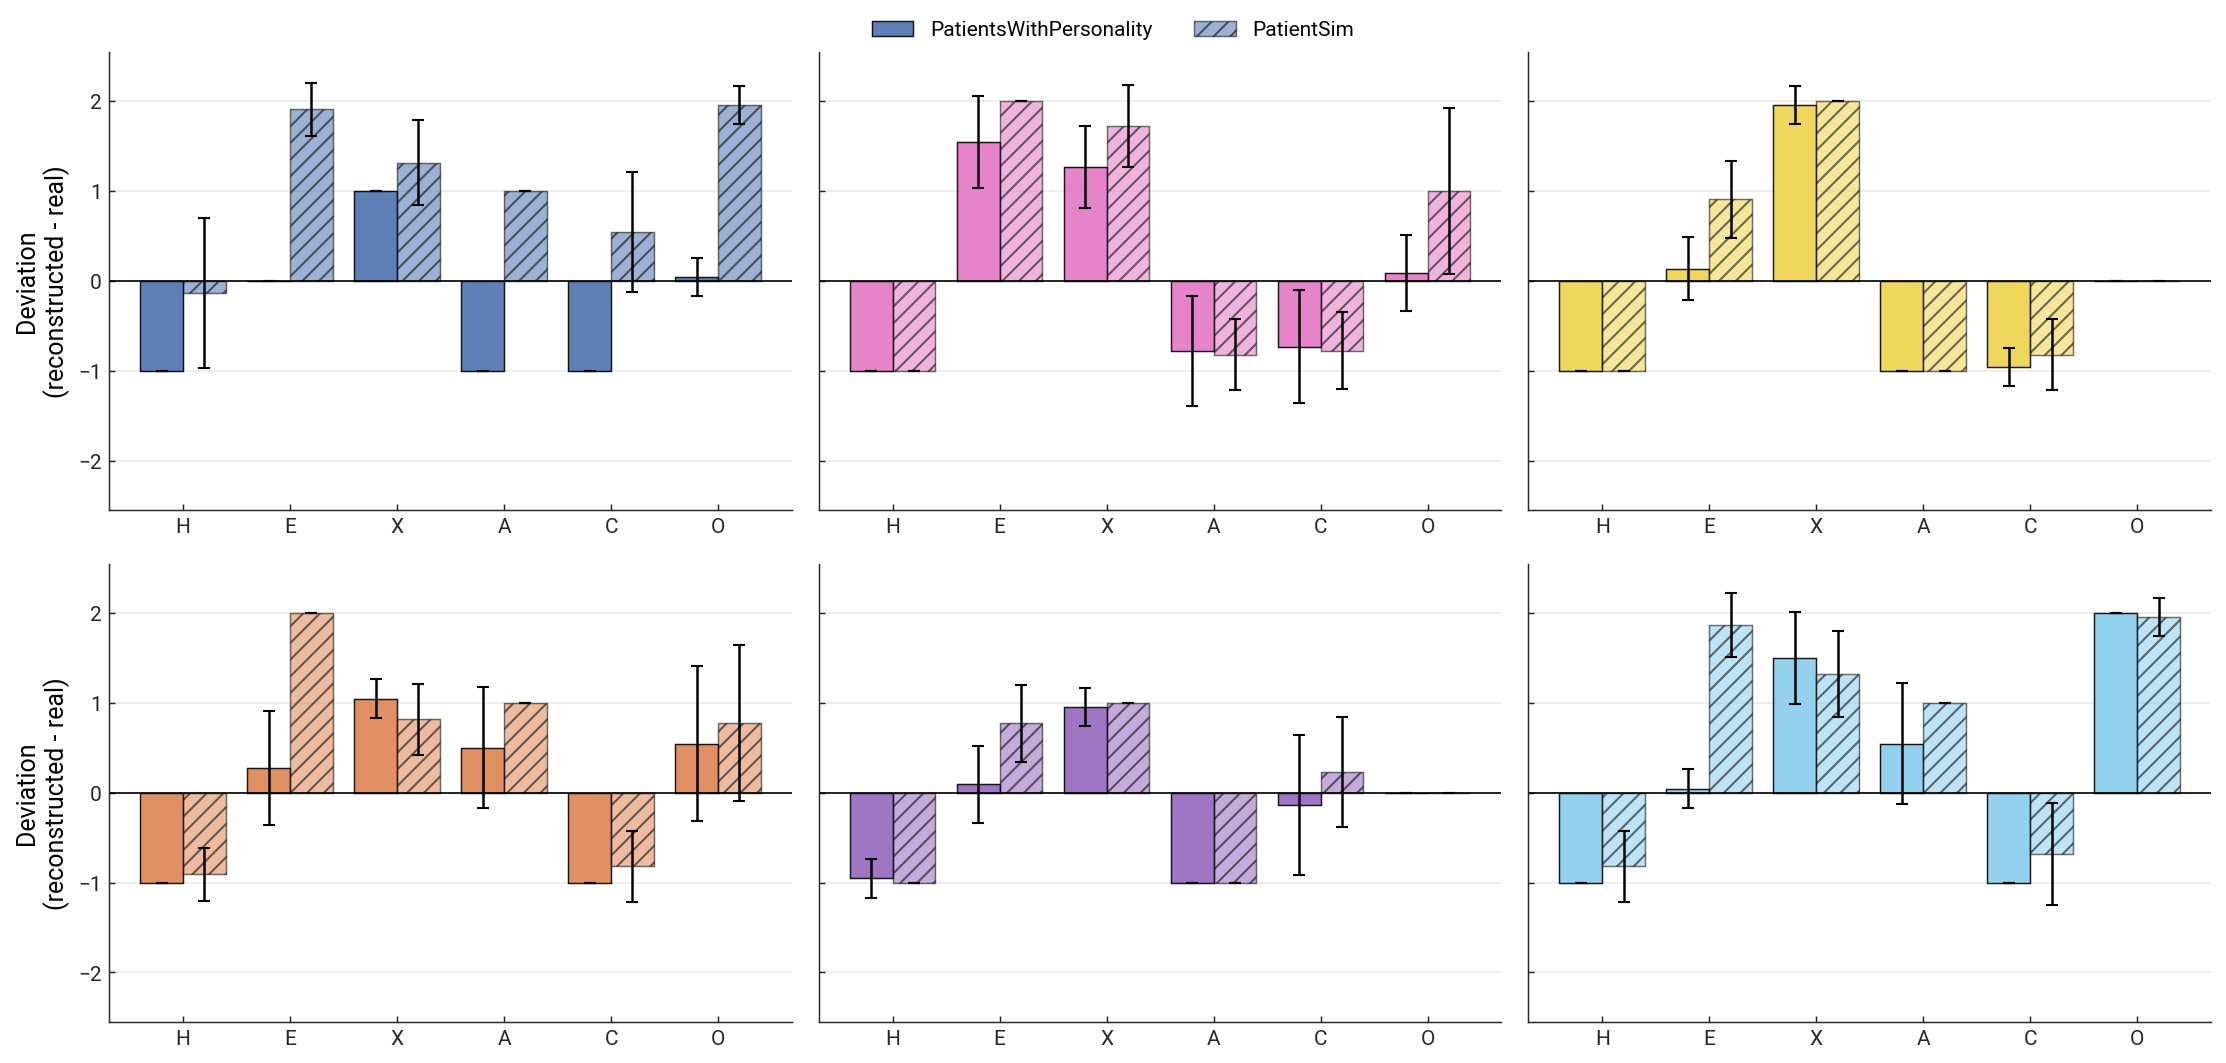

In [5]:
hexaco_stats = plot_hexaco_deviation_grid(
    res,
    persona_col="persona",
    simulator_col="simulator",
    palette=PERSONA_COLORS,
    persona_order=VARIANT_ORDER,
    simulator_order=SIMULATOR_ORDER,
    reference_vector=DEFAULT_HEXACO,
    ncols=3,
)

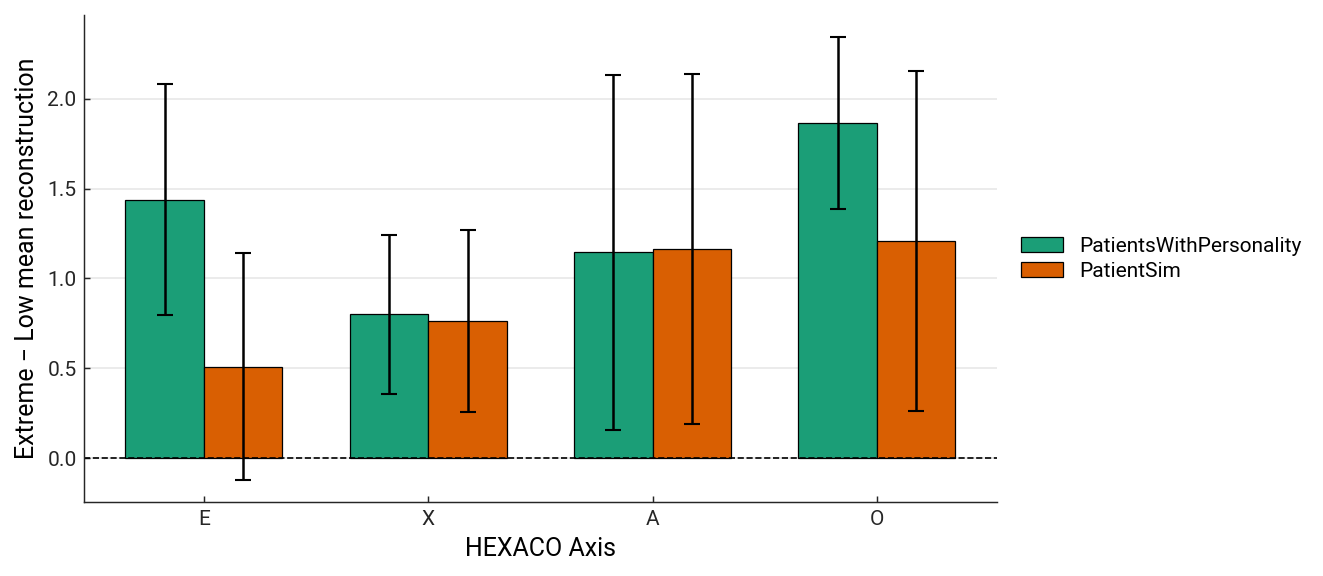

In [6]:
PERSONA_AXIS_MAP = {
    "Dishonest": "H",
    "Emotional": "E",
    "Extraverted": "X",
    "Frustrated/Skeptical": "A",
    "Disorganized": "C",
    "Cautious": "O",
}

res_extreme = res.copy()
res_extreme["hexaco_axis"] = res_extreme["persona"].map(PERSONA_AXIS_MAP)
res_extreme["rater"] = "Autorater"
res_extreme = res_extreme.dropna(subset=["hexaco_axis"])

plot_personality_extreme_difference(
    res_extreme,
    rater="Autorater",
    exclude_axes=["H", "C"],
    patient_type_col="simulator",
    axis_col="hexaco_axis",
    title="Personality Axis Discrimination: Extreme vs. Low (Autorater)",
    show_sd=True,
)

## 3. Conversational diversity (2-PC projection)

Embed each conversation's simulated-patient turns with a SOTA sentence encoder (`BAAI/bge-large-en-v1.5`), project to 2 PCs. Filled hulls show the coverage region of each simulator family; markers show per-persona centroids, colored by persona and shaped by simulator.

In [7]:
embeddings = embed_conversations(res)
embeddings.shape

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

(308, 1024)

In [8]:
pcs, evr = pca_nd(embeddings, n_components=2)
print(
    f"Explained variance ratio: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}, total={evr.sum():.3f}"
)

Explained variance ratio: PC1=0.073, PC2=0.065, total=0.138


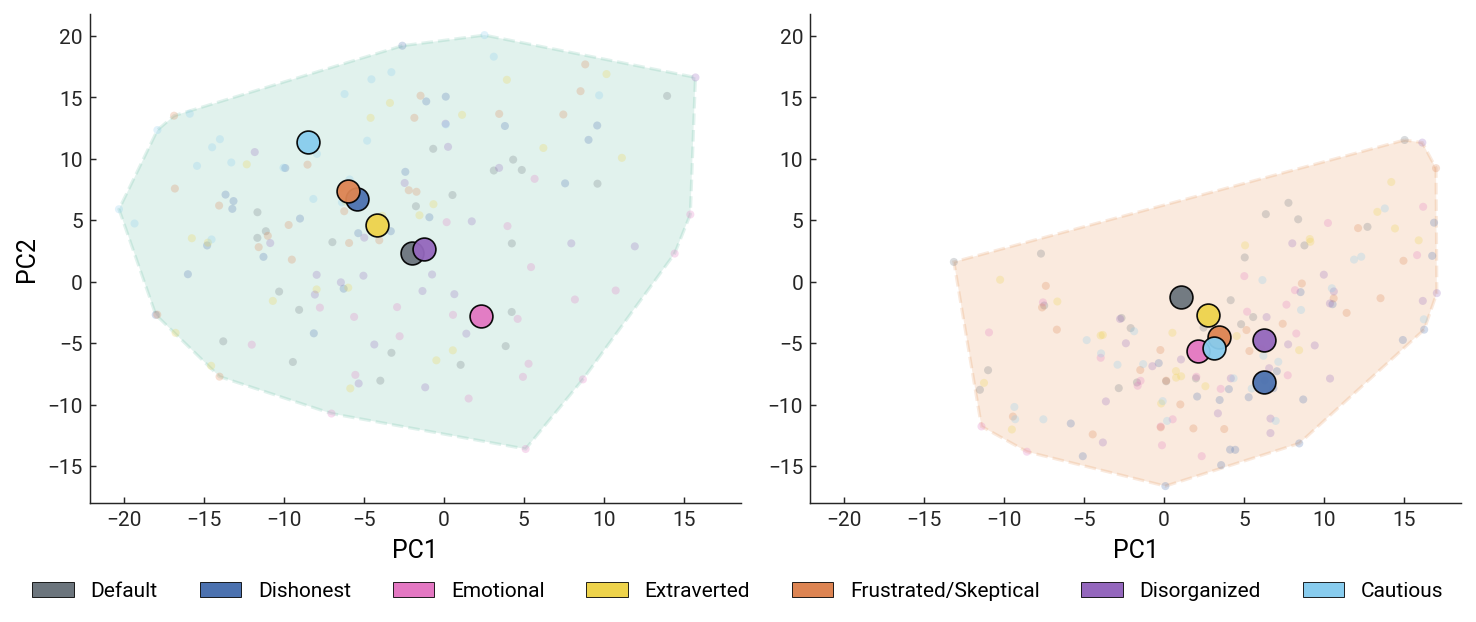

In [9]:
plot_diversity_overview(
    res,
    pcs,
    persona_col="persona",
    simulator_col="simulator",
    palette=PERSONA_COLORS,
    simulator_order=SIMULATOR_ORDER,
    persona_order=PERSONA_ORDER,
    save_as="personality_conversation_diversity",
);

In [10]:
per_combo = compute_diversity_stats(
    pcs, res[["simulator", "persona"]], embeddings=embeddings
)
per_sim = compute_diversity_stats(pcs, res[["simulator"]], embeddings=embeddings)
per_sim.insert(1, "persona", "overall")

table = pd.concat([per_combo, per_sim], ignore_index=True)
table["_sort"] = table["persona"].eq("overall").astype(int)
display(
    table.sort_values(
        ["simulator", "_sort", "mean_pairwise_dist"], ascending=[True, True, False]
    )
    .drop(columns="_sort")
    .reset_index(drop=True)
)

,simulator,persona,n,mean_pairwise_dist,std_pairwise_dist,hull_area,vendi_score
0,PatientSim,Extraverted,22,12.285986,6.963507,301.929645,3.245805
1,PatientSim,Emotional,22,12.072246,6.677211,315.359417,2.990292
2,PatientSim,Frustrated/Skeptical,22,12.056226,6.688767,309.381413,3.008179
3,PatientSim,Default,22,12.030404,6.634913,306.321038,3.459912
4,PatientSim,Cautious,22,11.224608,6.260972,232.005348,2.898975
5,PatientSim,Disorganized,22,10.473482,5.787467,277.130203,3.204446
6,PatientSim,Dishonest,22,10.232842,6.135131,214.970921,2.600471
7,PatientSim,overall,154,11.780138,6.615707,577.053332,4.232075
8,PatientsWithPersonality,Extraverted,22,14.396491,7.035510,462.727850,3.460305
9,PatientsWithPersonality,Default,22,13.031942,6.403509,349.823803,3.434523


In [11]:
metrics = {
    "Mean pairwise dist": ("mean_pairwise_dist", "std_pairwise_dist"),
    "Hull area": ("hull_area", None),
    "Vendi score": ("vendi_score", None),
}


def fmt_pm(row, mean_col, std_col):
    m = row[mean_col]
    if pd.isna(m):
        return "—"
    if std_col is not None and not pd.isna(row[std_col]):
        return f"{m:.2f} ± {row[std_col]:.2f}"
    return f"{m:.2f}"


pub = (
    table.assign(_order=table["persona"].eq("overall").astype(int))
    .sort_values(["_order", "persona", "simulator"])
    .drop(columns="_order")
    .set_index(["persona", "simulator"])
)

paper_table = pd.DataFrame(
    {
        label: pub.apply(lambda r: fmt_pm(r, mc, sc), axis=1)
        for label, (mc, sc) in metrics.items()
    },
    index=pub.index,
)
display(paper_table)

Mean pairwise dist Hull area  \
persona              simulator                                              
Cautious             PatientSim                    11.22 ± 6.26    232.01   
                     PatientsWithPersonality       11.15 ± 6.40    246.27   
Default              PatientSim                    12.03 ± 6.63    306.32   
                     PatientsWithPersonality       13.03 ± 6.40    349.82   
Dishonest            PatientSim                    10.23 ± 6.14    214.97   
                     PatientsWithPersonality       12.66 ± 6.68    332.69   
Disorganized         PatientSim                    10.47 ± 5.79    277.13   
                     PatientsWithPersonality       11.84 ± 6.34    417.45   
Emotional            PatientSim                    12.07 ± 6.68    315.36   
                     PatientsWithPersonality       11.74 ± 5.58    340.28   
Extraverted          PatientSim                    12.29 ± 6.96    301.93   
                     PatientsWithPersonality       14.40 ± 7.04    462.73   
Frustrated/Skeptical PatientSim                    12.06 ± 6.69    309.38   
                     PatientsWithPersonality       12.54 ± 7.23    343.12   
overall              PatientSim                    11.78 ± 6.62    577.05   
                     PatientsWithPersonality       14.12 ± 7.01    888.52   

                                             Vendi score  
persona              simulator                            
Cautious             PatientSim                     2.90  
                     PatientsWithPersonality        3.74  
Default              PatientSim                     3.46  
                     PatientsWithPersonality        3.43  
Dishonest            PatientSim                     2.60  
                     PatientsWithPersonality        3.82  
Disorganized         PatientSim                     3.20  
                     PatientsWithPersonality        3.36  
Emotional            PatientSim                     2.99  
                     PatientsWithPersonality        3.80  
Extraverted          PatientSim                     3.25  
                     PatientsWithPersonality        3.46  
Frustrated/Skeptical PatientSim                     3.01  
                     PatientsWithPersonality        3.82  
overall              PatientSim                     4.23  
                     PatientsWithPersonality        5.48

## 4. Information handling by H and C levels

For PatientsWithPersonality, compare token recall between `sim_profile.json` and the ground-truth profile across field types:

- **H axis → leisure fields** (tobacco, alcohol, drugs, exercise, sexual history): high H (dishonest) should suppress disclosure.
- **C axis → medical fields** (medications, medical history, symptoms, …): high C (disorganized) should reduce recall of clinical detail.

In [12]:
from patient_simulator.misc.profile_comparison import (
    compute_profile_recalls,
    compute_persona_recalls,
    plot_information_handling,
    plot_information_handling_comparison,
)

# H/C trend: PatientsWithPersonality only, grouped by param_h / param_c
recall_df = compute_profile_recalls(res, data_dir="data/aci_bench/extracted_profiles")

# Cross-simulator comparison — controlled baselines:
#   PatientsWithPersonality baseline = H=1, C=1 (4 personas: Emotional/Extraverted/Frustrated/Cautious)
#     → Dishonest (H=3, C=1): only H changes
#     → Disorganized (H=1, C=3): only C changes
#   PatientSimPatient baseline = Default (persplain, recallhigh)
COMPARISON_PERSONAS = {
    # PP baseline: H=1, C=1 (four personas; only the axis under test changes)
    "PatientsWithPersonality_H1_E3_X1_A1_C1_O1_LB": "Default",
    "PatientsWithPersonality_H1_E1_X3_A1_C1_O1_LB": "Default",
    "PatientsWithPersonality_H1_E1_X1_A3_C1_O1_LB": "Default",
    "PatientsWithPersonality_H1_E1_X1_A1_C1_O3_LB": "Default",
    "PatientsWithPersonality_H3_E1_X1_A1_C1_O1_LB": "Dishonest",  # only H: 1→3
    "PatientsWithPersonality_H1_E1_X1_A1_C3_O1_LB": "Disorganized",  # only C: 1→3
    # PSP baseline: plain default
    "PatientSimPatient_persplain_cefrB_dazednormal_recallhigh": "Default",
    "PatientSimPatient_persdistrust_cefrB_dazednormal_recalllow": "Dishonest",
    "PatientSimPatient_persplain_cefrB_dazedhigh_recalllow": "Disorganized",
}
res_cmp = res[res["patient_name"].isin(COMPARISON_PERSONAS)].copy()
res_cmp["persona"] = res_cmp["patient_name"].map(COMPARISON_PERSONAS)
persona_recall_df = compute_persona_recalls(
    res_cmp, data_dir="data/aci_bench/extracted_profiles"
)

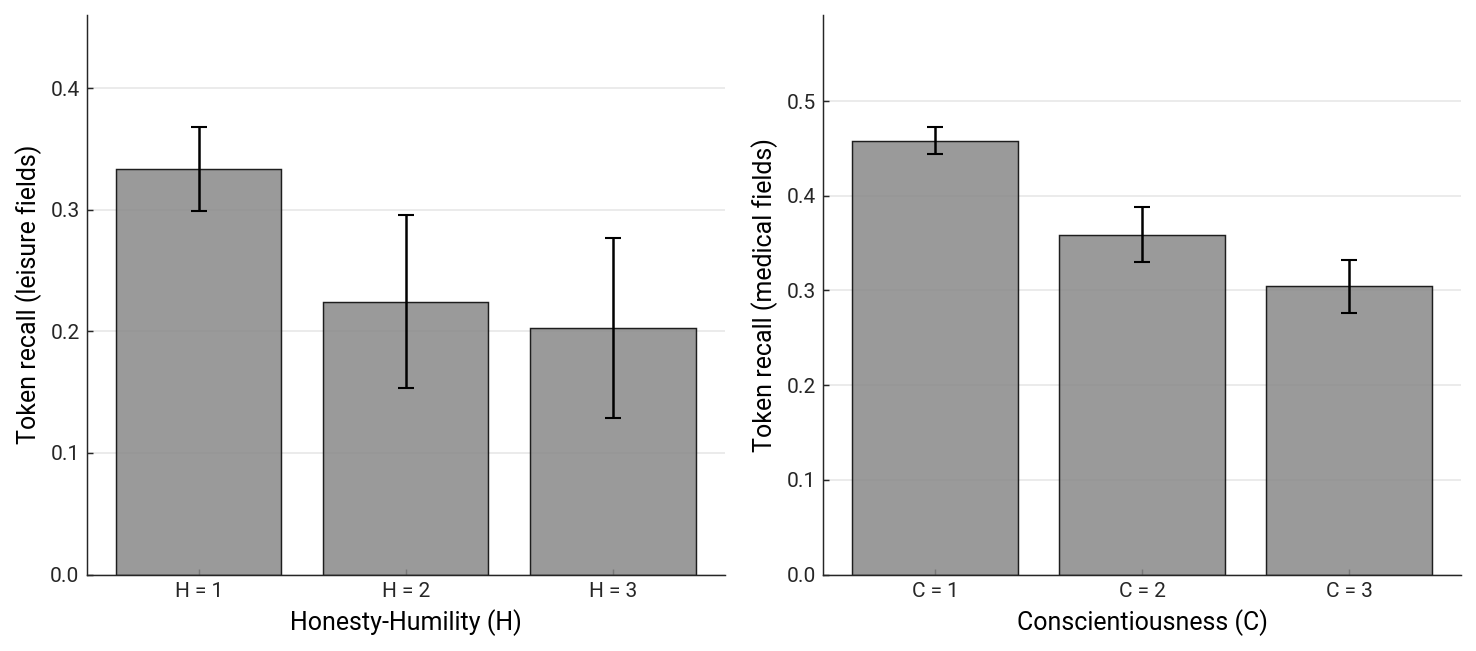

In [13]:
plot_information_handling(recall_df);

                 simulator       persona field_type     delta  delta_sem
0               PatientSim     Dishonest    leisure -0.079681   0.110615
1               PatientSim     Dishonest    medical -0.093460   0.044506
2               PatientSim  Disorganized    leisure -0.046173   0.109051
3               PatientSim  Disorganized    medical -0.123024   0.043248
4  PatientsWithPersonality     Dishonest    leisure -0.133328   0.083661
5  PatientsWithPersonality     Dishonest    medical  0.011185   0.036348
6  PatientsWithPersonality  Disorganized    leisure -0.015050   0.085634
7  PatientsWithPersonality  Disorganized    medical -0.151644   0.032555


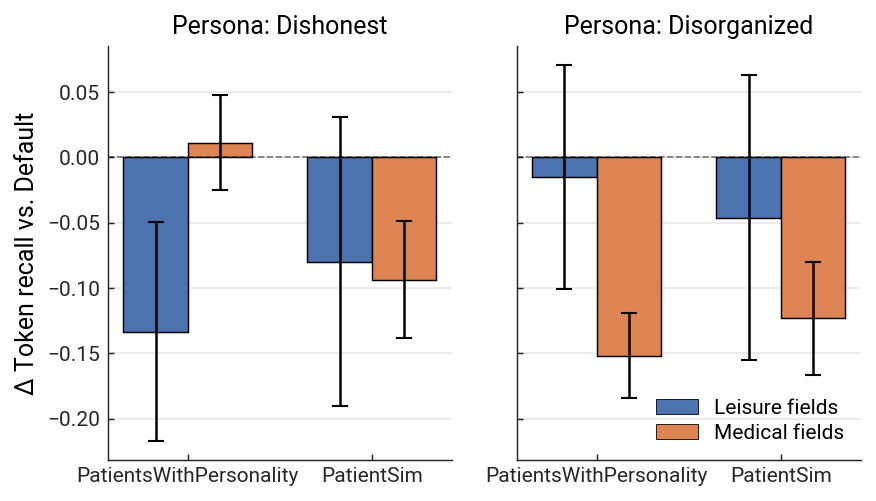

In [14]:
plot_information_handling_comparison(
    persona_recall_df,
    simulator_order=SIMULATOR_ORDER,
    extreme_personas=("Dishonest", "Disorganized"),
    save_as="personality_info_handling_comp",
);